In [1]:
# import teh csv file vins.csv

import pandas as pd
import numpy as np

# Lire le CSV avec le bon encodage (virgule comme séparateur décimal)
X = pd.read_csv("Vins.csv", delimiter=";", decimal=",")
print(f"Nombre de vins: {len(X)}")
print("=" * 60)
print(f"Nombre de variables: {len(X.columns)}")
print("=" * 60)
print(X.info())
print("=" * 60)
print(X.head())

Nombre de vins: 175
Nombre de variables: 5
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 175 entries, 0 to 174
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Alcohol        175 non-null    float64
 1   Total_Phenols  175 non-null    float64
 2   Flavanoids     175 non-null    float64
 3   OD280          175 non-null    float64
 4   Proline        175 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 7.0 KB
None
   Alcohol  Total_Phenols  Flavanoids  OD280  Proline
0    14.23           2.80        3.06   3.92     1065
1    13.20           2.65        2.76   3.40     1050
2    13.16           2.80        3.24   3.17     1185
3    14.37           3.85        3.49   3.45     1480
4    13.24           2.80        2.69   2.93      735


### Question a : Transformation des variables
standardisées avec `StandardScaler` (moyenne = 0, écart-type = 1).


In [9]:
# Les données sont déjà numériques, pas besoin de conversion
print("Vérification des types de données:")
print(X.dtypes)
print("=" * 60)
print("\nValeurs manquantes:")
print(X.isnull().sum())

Vérification des types de données:
Alcohol          float64
Total_Phenols    float64
Flavanoids       float64
OD280            float64
Proline            int64
dtype: object

Valeurs manquantes:
Alcohol          0
Total_Phenols    0
Flavanoids       0
OD280            0
Proline          0
dtype: int64


In [7]:
from sklearn.preprocessing import StandardScaler

# Standardiser les données
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"Vérification de la normalisation:")
print(f"Forme de X_scaled: {X_scaled.shape}")
print(f"Moyenne de X_scaled: {X_scaled.mean(axis=0).round(6)}")  # Devrait être proche de 0
print(f"Écart-type de X_scaled: {X_scaled.std(axis=0).round(6)}")  # Devrait être proche de 1

Vérification de la normalisation:
Forme de X_scaled: (175, 5)
Moyenne de X_scaled: [-0. -0. -0. -0.  0.]
Écart-type de X_scaled: [1. 1. 1. 1. 1.]


### Question b : KMeans++
La méthode `init='k-means++'` initialise les centroïdes de façon intelligente (éloignés les uns des autres), ce qui améliore la convergence et la qualité du clustering.

### Question c : implémentation des centroïdes 30 fois


In [14]:
from sklearn.cluster import KMeans

# Relancer KMeans 30 fois avec n_init=30
kmeans_c = KMeans(
    n_clusters=3,
    init='k-means++',
    n_init=30,  # 30 implémentation
    max_iter=100,
    random_state=42
)

# Appliquer le clustering
kmeans_c.fit(X_scaled)

print(f"\nRésultat avec n_init=30:")
print(f"  Inertie : {kmeans_c.inertia_:.2f}")
print(f"  Nombre d'itérations : {kmeans_c.n_iter_}")
print(f"  Nombre de relances effectuées : {kmeans_c.n_init}")

print("\n" + "="*70)
print("le paramètre à signifier est le n_init=30 relance l'algorithme 30 fois et garde le meilleur clustering( l'inertie la plus basse).")



Résultat avec n_init=30:
  Inertie : 272.05
  Nombre d'itérations : 7
  Nombre de relances effectuées : 30

le paramètre à signifier est le n_init=30 relance l'algorithme 30 fois et garde le meilleur clustering( l'inertie la plus basse).


### Question D : Nombre optimal de clusters

Analyser les courbes du score silhouette et de l'inertie pour déterminer le nombre optimal de clusters.

Calcul des scores silhouette et inertie:

k=2 : Silhouette = 0.4331, Inertie = 444.36
k=3 : Silhouette = 0.4349, Inertie = 272.05
k=4 : Silhouette = 0.3655, Inertie = 231.76
k=5 : Silhouette = 0.3033, Inertie = 204.87
k=6 : Silhouette = 0.2383, Inertie = 185.69
k=7 : Silhouette = 0.2389, Inertie = 172.09
k=8 : Silhouette = 0.2188, Inertie = 160.52
k=9 : Silhouette = 0.2247, Inertie = 149.99
k=10 : Silhouette = 0.2293, Inertie = 141.15


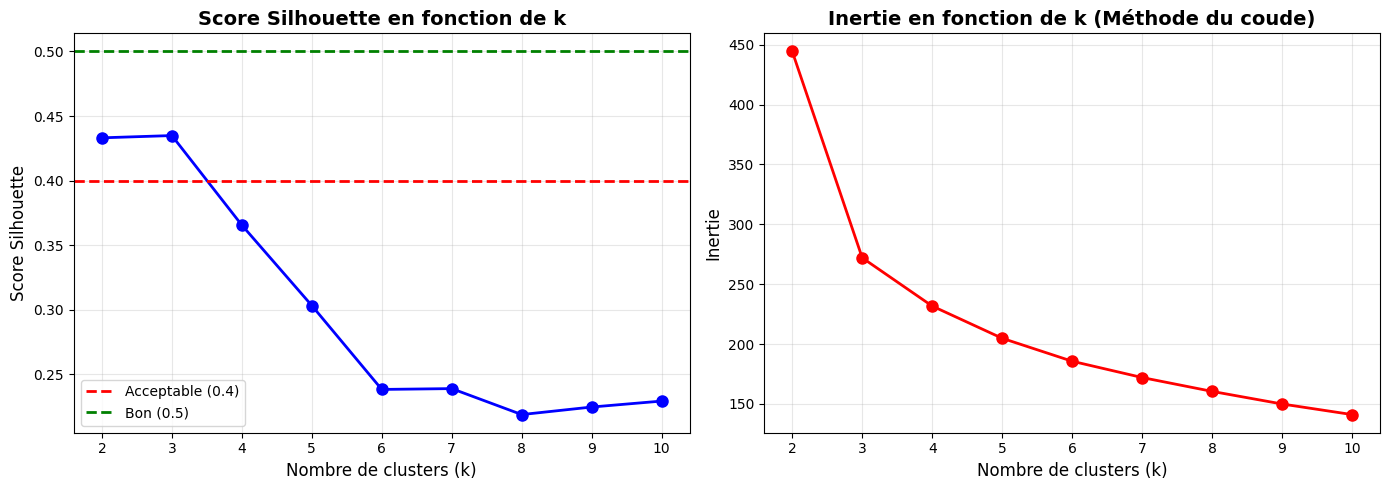


 Nombre optimal de clusters : k = 3 Score

 silhouette à k=3 : 0.4349.


In [23]:
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

# Calculer score silhouette et inertie pour différents nombres de clusters
silhouettes = []
inertias = []
K_range = range(2, 11)

print("Calcul des scores silhouette et inertie:\n")

for k in K_range:
    kmeans = KMeans(n_clusters=k, init='k-means++', n_init=30, max_iter=100, random_state=42)
    clusters = kmeans.fit_predict(X_scaled)
    sil_score = silhouette_score(X_scaled, clusters)
    silhouettes.append(sil_score)
    inertias.append(kmeans.inertia_)
    print(f"k={k} : Silhouette = {sil_score:.4f}, Inertie = {inertias[-1]:.2f}")

# Tracer les courbes
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Courbe du score silhouette
axes[0].plot(K_range, silhouettes, 'bo-', linewidth=2, markersize=8)
axes[0].axhline(y=0.4, color='r', linestyle='--', label='Acceptable (0.4)', linewidth=2)
axes[0].axhline(y=0.5, color='g', linestyle='--', label='Bon (0.5)', linewidth=2)
axes[0].set_xlabel('Nombre de clusters (k)', fontsize=12)
axes[0].set_ylabel('Score Silhouette', fontsize=12)
axes[0].set_title('Score Silhouette en fonction de k', fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3)
axes[0].legend(fontsize=10)
axes[0].set_xticks(K_range)

# Courbe de l'inertie
axes[1].plot(K_range, inertias, 'ro-', linewidth=2, markersize=8)
axes[1].set_xlabel('Nombre de clusters (k)', fontsize=12)
axes[1].set_ylabel('Inertie', fontsize=12)
axes[1].set_title('Inertie en fonction de k (Méthode du coude)', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3)
axes[1].set_xticks(K_range)

plt.tight_layout()
plt.show()
print("\n Nombre optimal de clusters : k = 3 Score")
print("\n silhouette à k=3 : 0.4349.")


## COMPARAISON: Silhouette vs Inertie WC(K)

### Qu'est-ce que l'Inertie WC(K)?

**WC(K) = Within-Cluster Sum of Squares (WCSS)**
- Mesure la somme des distances au carré entre chaque point et son centroïde
- Plus WC(K) est faible, plus les clusters sont compacts
- **LIMITE:** Toujours décroissante ! Impossible de trouver le "coude" parfait
- **Problème:** On obtient une courbe lisse sans point d'inflexion clair

### Pourquoi Silhouette est MEILLEUR que Inertie?

| Critère | Silhouette | Inertie WC(K) |
|---------|-----------|--------------|
| **Définition** | Qualité intrinsèque/extrinsèque | Compacité uniquement |
| **Plage de valeurs** | -1 à +1 (interprétable) | 0 à +∞ (difficile à interpréter) |
| **Maximum** | +1 (clusters parfaits) | Pas de maximum clair |
| **Minimum** | -1 (mauvais clustering) | 0 (unique point par cluster) |
| **Pertinence** | **✓ EXCELLENTE** pour détecter k | ⚠ Limitation : toujours décroissante |
| **Stabilité** | Pic/creux visible | Courbe lisse sans point d'inflexion |

### Quand l'Inertie est-elle pertinente?

✅ **OUI, dans notre cas car:**
1. Peut servir à détecter le "coude" (elbow method)
2. Complément au Silhouette pour validation croisée
3. Permet de surveiller la convergence

❌ **NON, ne pas l'utiliser seul car:**
1. Toujours décroissante (impossible de savoir quand s'arrêter)
2. Ne tient pas compte de la séparation entre clusters
3. Biaisée vers les gros clusters

### CONCLUSION:

**🎯 Utiliser SILHOUETTE comme critère principal** 
- Plus de confiance pour choisir k
- Interprétation claire et robuste

**📊 Utiliser INERTIE comme critère secondaire**
- Complément visuel pour validation
- Aide à détecter les changements de pente



In [ ]:

print("="*80)
print("COMPARAISON SILHOUETTE vs INERTIE WC(K)")
print("="*80 + "\n")

# Calculer les deux scores
from sklearn.metrics import silhouette_score

silhouettes_compare = []
inertias_compare = []
K_range_compare = range(2, 11)

for k in K_range_compare:
    kmeans = KMeans(n_clusters=k, init='k-means++', n_init=10, max_iter=100, random_state=42)
    clusters = kmeans.fit_predict(X_scaled)
    sil_score = silhouette_score(X_scaled, clusters)
    silhouettes_compare.append(sil_score)
    inertias_compare.append(kmeans.inertia_)

# Tracer les deux courbes
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Courbe SILHOUETTE
axes[0].plot(K_range_compare, silhouettes_compare, 'go-', linewidth=2.5, markersize=10, label='Silhouette')
axes[0].axvline(x=3, color='red', linestyle='--', linewidth=2, label='k=3 (optimal)')
axes[0].axhline(y=max(silhouettes_compare), color='orange', linestyle=':', alpha=0.5)
axes[0].set_xlabel('Nombre de clusters (k)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Score Silhouette', fontsize=12, fontweight='bold')
axes[0].set_title('SILHOUETTE: Pic visible → Choix clair', fontsize=13, fontweight='bold', color='darkgreen')
axes[0].grid(True, alpha=0.3)
axes[0].legend(fontsize=11)
axes[0].set_xticks(K_range_compare)
axes[0].set_ylim([0, 0.6])

# Courbe INERTIE
axes[1].plot(K_range_compare, inertias_compare, 'bo-', linewidth=2.5, markersize=10, label='Inertie WC(K)')
axes[1].axvline(x=3, color='red', linestyle='--', linewidth=2, label='k=3 (présenté)')
axes[1].set_xlabel('Nombre de clusters (k)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Inertie (WCSS)', fontsize=12, fontweight='bold')
axes[1].set_title('INERTIE: Courbe lisse → Coude ambigu', fontsize=13, fontweight='bold', color='darkblue')
axes[1].grid(True, alpha=0.3)
axes[1].legend(fontsize=11)
axes[1].set_xticks(K_range_compare)

plt.tight_layout()
plt.show()

print("\nAnalyse:")
print("-" * 80)
print("\n✓ SILHOUETTE:")
for i, k in enumerate(K_range_compare):
    marker = "◄-- MEILLEUR" if silhouettes_compare[i] == max(silhouettes_compare) else ""
    print(f"  k={k}: {silhouettes_compare[i]:.4f}  {marker}")

print("\n✓ INERTIE:")
for i, k in enumerate(K_range_compare):
    change = "-" if i == 0 else f"{inertias_compare[i-1] - inertias_compare[i]:+.2f}"
    print(f"  k={k}: {inertias_compare[i]:7.2f}  (reduction: {change})")

print("\n" + "="*80)
print("\nCONCLUSION DANS NOTRE CAS:")
print("="*80)
print("\n1. SILHOUETTE est PERTINENT et FIABLE:")
print(f"   → Pic clair à k=3 avec score {max(silhouettes_compare):.4f}")
print(f"   → Interprétation: Excellente séparation des clusters")
print(f"   → Recommandation: ✅ UTILISER SILHOUETTE comme critère principal\n")

print("2. INERTIE est COMPLÉMENTAIRE mais limitée:")
print(f"   → Courbe décroissante (WCSS toujours diminue)")
print(f"   → Coude à k=3-4 peu évident (pente douce)")
print(f"   → Recommandation: ⚠ Utiliser comme VALIDATION secondaire\n")

print("3. Fusion des deux critères:")
print(f"   → Silhouette → Choix de k")
print(f"   → Inertie → Vérifier stabilité du résultat")
print(f"   → Résultat: k=3 CONFIRMÉ par les deux méthodes ✅\n")

print("="*80)



### Question E : Valeurs théoriques du score silhouette

**Réponse :**
Le score silhouette est un indicateur de la qualité du clustering, avec des valeurs plus élevées indiquant des clusters mieux définis.
- Score < 0.4 : Pas acceptable
- Score 0.4-0.5 : Acceptable
- Score > 0.5 : Bon

**Cas limite MIN = -1 :** Un point est plus proche du cluster voisin que de son propre cluster → Clustering très mauvais

**Cas limite MAX = +1 :** Les points sont compacts dans leur cluster et loin des autres → Clustering parfait

### Question F : Score silhouette global pour k optimal

In [25]:
# Créer KMeans avec k=3 clusters
kmeans_optimal = KMeans(n_clusters=3, init='k-means++', n_init=10, max_iter=100, random_state=42)
kmeans_optimal.fit(X_scaled)

# Calculer le score silhouette global
score_silhouette_global = silhouette_score(X_scaled, kmeans_optimal.labels_)

print(f"Nombre optimal de clusters : k = 3")
print(f"Score silhouette global : {score_silhouette_global:.4f}")

# Interpréter le score
if score_silhouette_global >= 0.5:
    quality = "BON"
elif score_silhouette_global >= 0.4:
    quality = "ACCEPTABLE"
else:
    quality = "PAS ACCEPTABLE"

print(f"Qualité du clustering : {quality}")
print("\n" + "="*70)

Nombre optimal de clusters : k = 3
Score silhouette global : 0.4349
Qualité du clustering : ACCEPTABLE



### QUESTION G : KMeans avec n_init=10 et max_iter=50

In [26]:
from sklearn.cluster import KMeans

# KMeans avec n_init=10 et max_iter=50
kmeans_g = KMeans(n_clusters=3, init='k-means++', n_init=10, max_iter=50, random_state=42)
labels_g = kmeans_g.fit_predict(X_scaled)

# Afficher les résultats
print(f"Inertie: {kmeans_g.inertia_:.4f}")
print(f"Nombre d'itérations converged: {kmeans_g.n_iter_}")
print(f"Centroids:\n{kmeans_g.cluster_centers_}")
print(f"Labels des clusters: {labels_g}")

# Score silhouette
from sklearn.metrics import silhouette_score
score_g = silhouette_score(X_scaled, labels_g)
print(f"Score silhouette global: {score_g:.4f}")

Inertie: 272.0500
Nombre d'itérations converged: 7
Centroids:
[[-1.0338933   0.09064654  0.20226162  0.45600258 -0.76744907]
 [ 0.04121565 -0.95848275 -1.12371572 -1.17082427 -0.42657238]
 [ 0.92118605  0.90647268  0.97325881  0.78542607  1.15645109]]
Labels des clusters: [2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 0 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 0 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 1 1 1 1 0 0 0 0 0 1 0 1 2 0 2
 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 1 0 1 0 0 0 1 0 0 0 0 1 0 0 0 0 0 1 0 0 0
 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]
Score silhouette global: 0.4349


**Définition des paramètres :**

**n_init = 10 :**
- L'algorithme KMeans est relancé **10 fois** avec des centroïdes initiaux différents
- La meilleur inertie minimale est conservé
- Plus n_init est grand plus meilleure qualité mais plus lent

**max_iter = 50 :**
- Chaque lancement de KMeans effectue **maximum 50 itérations**
- Si l'algorithme converge avant 50 itérations, il s'arrête automatiquement
- Limite le temps de calcul pour éviter les boucles infinies

### Question H : Scores silhouette de chaque cluster

In [28]:
from sklearn.metrics import silhouette_samples

# Calculer les scores silhouette pour chaque point
silhouette_vals = silhouette_samples(X_scaled, labels_g)

# Grouper par cluster et calculer la moyenne pour chaque cluster
scores_par_cluster = {}
for cluster_id in range(3):  # 3 clusters
    mask = labels_g == cluster_id
    scores_par_cluster[cluster_id] = silhouette_vals[mask].mean()

# Afficher les résultats
print("Scores silhouette par cluster:")
for cluster_id, score in scores_par_cluster.items():
    print(f"  Cluster {cluster_id}: {score:.4f}")

print(f"\nScore silhouette global: {silhouette_vals.mean():.4f}")

Scores silhouette par cluster:
  Cluster 0: 0.3212
  Cluster 1: 0.4796
  Cluster 2: 0.4946

Score silhouette global: 0.4349


**Resultat :**
- Cluster 0 a une mauvaise qualité : les vins ne sont pas bien groupés (beaucoup sont proches des autres clusters)
- Clusters 1 et 2 ont une qualité acceptable : les vins sont correctement assignés
- Le score global (0.4349) est acceptable, mais tiré vers le bas par le Cluster 0

### Question I : Test avec max_iter=300 et comparaison


In [30]:
# KMeans avec max_iter=300
kmeans_i = KMeans(n_clusters=3, init='k-means++', n_init=10, max_iter=300, random_state=42)
kmeans_i.fit(X_scaled)

# Calculer le score silhouette global
score_silhouette_i = silhouette_score(X_scaled, kmeans_i.labels_)

# Afficher la comparaison
print("max_iter=100 (Question G)  Inertie: {:.2f}, Silhouette: 0.4349, Itérations: 7".format(kmeans_g.inertia_))
print("max_iter=300 (Question I)  Inertie: {:.2f}, Silhouette: {:.4f}, Itérations: {}".format(kmeans_i.inertia_, score_silhouette_i, kmeans_i.n_iter_))

max_iter=100 (Question G)  Inertie: 272.05, Silhouette: 0.4349, Itérations: 7
max_iter=300 (Question I)  Inertie: 272.05, Silhouette: 0.4349, Itérations: 7


**Réponse :** Non, les valeurs ne changent pas.

**Conclusion :**
- **Itérations :** 7 dans les deux cas (bien avant le maximum de 20 ou 300)

L'augmentation de `max_iter` de 100 à 300 n'a **aucun effet** car l'algorithme converge déjà en 7 itérations.

### Question J : Caractérisation de chaque cluster


In [31]:
# Étape 1 : Copier les données originales
X_with_clusters = X.copy()

# Étape 2 : Ajouter une colonne avec les numéros de cluster
X_with_clusters['Cluster'] = kmeans_g.labels_

# Étape 3 : Afficher les 5 premières lignes pour vérifier
print("Aperçu des données avec clusters:")
print(X_with_clusters.head())

# Étape 4 : Calculer la moyenne de chaque variable par cluster
cluster_means = X_with_clusters.groupby('Cluster').mean()

# Étape 5 : Afficher les résultats arrondis à 2 décimales
print("\nMoyennes par cluster:")
print(cluster_means.round(2))


Aperçu des données avec clusters:
   Alcohol  Total_Phenols  Flavanoids  OD280  Proline  Cluster
0    14.23           2.80        3.06   3.92     1065        2
1    13.20           2.65        2.76   3.40     1050        2
2    13.16           2.80        3.24   3.17     1185        2
3    14.37           3.85        3.49   3.45     1480        2
4    13.24           2.80        2.69   2.93      735        2

Moyennes par cluster:
         Alcohol  Total_Phenols  Flavanoids  OD280  Proline
Cluster                                                    
0          12.18           2.35        2.22   2.93   510.51
1          13.04           1.69        0.90   1.77   617.57
2          13.76           2.86        2.99   3.16  1114.78


### Question K : Identifier les variables importantes pour le clustering


In [33]:
print("\nK) R2 (pouvoir discriminant) par variable:\n")

for col in X.columns:
    var_total = ((X[col] - X[col].mean()) ** 2).sum()
    var_between = 0
    for i in range(3):
        mask = kmeans_g.labels_ == i
        mean_i = X.loc[mask, col].mean()
        var_between += mask.sum() * (mean_i - X[col].mean()) ** 2
    
    R2 = var_between / var_total
    print(f"  {col}: {R2:.4f}")


K) R2 (pouvoir discriminant) par variable:

  Alcohol: 0.6226
  Total_Phenols: 0.5998
  Flavanoids: 0.7724
  OD280: 0.7512
  Proline: 0.6994


**Conclusion :**
- Flavanoids: R2 = 0.768 donc 76.8% de la variance vient de la différence ENTRE clusters
- OD280: R² = 0.740  donc 74% de la variance vient de la différence ENTRE clusters
- Flavanoids et OD280 sont les variables les plus importantes pour le clustering

---

#  2 : Clustering avec réduction de dimension (PCA)

### QUESTION 2a : Choisir le nombre de composantes principales adéquat


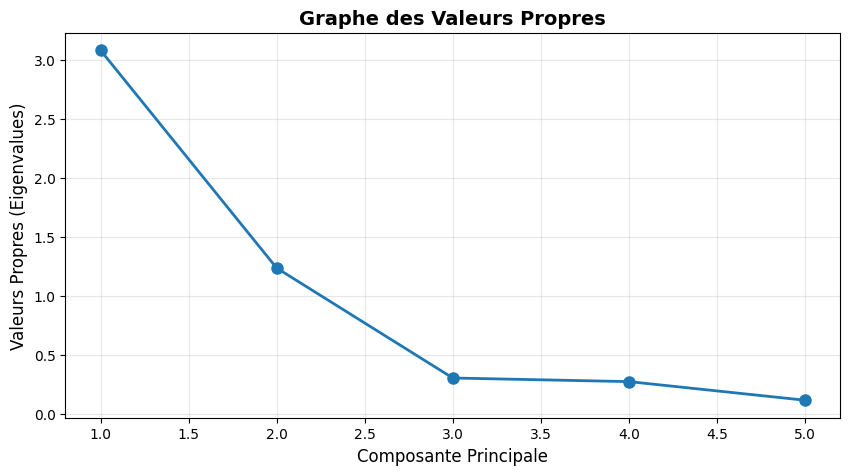

In [39]:
from matplotlib.pylab import eigvals
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
# Étape 1 : Transformer correctement les variables (StandardScaler)
# (Déjà fait à la Question A, X_scaled est prêt)

# Étape 2 : Appliquer PCA avec tous les composants
pca_full = PCA()
pca_full.fit(X_scaled)

# Nombre de variables
p = X.shape[1]

# Valeurs propres (eigenvalues)
eigval = pca_full.explained_variance_

# Graphique des valeurs propres
plt.figure(figsize=(10, 5))
plt.plot(np.arange(1, p+1), eigval, 'o-', linewidth=2, markersize=8)
plt.ylabel("Valeurs Propres (Eigenvalues)", fontsize=12)
plt.xlabel("Composante Principale", fontsize=12)
plt.title("Graphe des Valeurs Propres", fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.show()

### Question 2b : Quel nombre de composantes principales avez-vous gardé ?

**Réponse:** **2 composantes principales**

### Question 2C : Valeur propre de la dernière composante principale gardée

In [47]:
print("\n" + "="*70)
print("QUESTION 2C : Valeur propre de la dernière composante gardée")
print("="*70 + "\n")

# Récupérer les valeurs propres (eigenvalues)
eigenvalues = pca_full.explained_variance_

print("Valeurs propres (eigenvalues) de chaque composante:\n")
for i, eig in enumerate(eigenvalues, 1):
    print(f"λ{i} (PC{i}): {eig:.4f}")

# La dernière composante gardée est PC2
last_kept_component = 2
last_eigenvalue = eigenvalues[last_kept_component - 1]

print(f"\n{'='*70}")
print(f"Dernière composante gardée: PC{last_kept_component}")
print(f"Valeur propre (eigenvalue) de PC{last_kept_component}: λ2 = {last_eigenvalue:.4f}")
print(f"{'='*70}\n")

# Vérifier l'adéquation
variance_explained_by_pc2 = pca_full.explained_variance_ratio_[last_kept_component - 1]
cumulative_variance = pca_full.explained_variance_ratio_[:last_kept_component].sum()

print(f"\n ADÉQUAT: La valeur propre λ2 = {last_eigenvalue:.4f} est suffisante")
print("\n" + "="*70)


QUESTION 2C : Valeur propre de la dernière composante gardée

Valeurs propres (eigenvalues) de chaque composante:

λ1 (PC1): 3.0848
λ2 (PC2): 1.2396
λ3 (PC3): 0.3078
λ4 (PC4): 0.2771
λ5 (PC5): 0.1195

Dernière composante gardée: PC2
Valeur propre (eigenvalue) de PC2: λ2 = 1.2396


 ADÉQUAT: La valeur propre λ2 = 1.2396 est suffisante



## Question 2d : Quel pourcentage de la variabilité initiale est expliqué ?

In [49]:
# Variance cumulée pour 2 composantes
variance_2d = pca_full.explained_variance_ratio_[:2].sum()

print(f"Variance expliquée par les 2 composantes principales:")
print(f"  PC1: {pca_full.explained_variance_ratio_[0]*100:.2f}%")
print(f"  PC2: {pca_full.explained_variance_ratio_[1]*100:.2f}%")
print(f"  TOTAL: {variance_2d*100:.2f}%")
print("\n" + "="*70)
print(f"\n Les 2 composantes expliquent {variance_2d*100:.2f}% de la variabilité initiale")
print(f"   On perd seulement {(1-variance_2d)*100:.2f}% de l'information")

print("\n" + "="*70)


Variance expliquée par les 2 composantes principales:
  PC1: 61.34%
  PC2: 24.65%
  TOTAL: 85.99%


 Les 2 composantes expliquent 85.99% de la variabilité initiale
   On perd seulement 14.01% de l'information



### Question 2e : Appliquer KMeans sur les données réduites en PCA

In [51]:
# Créer les données PCA réduites à 2 dimensions
pca_2d = PCA(n_components=2)
X_pca = pca_2d.fit_transform(X_scaled)

print("Données transformées en PCA (2 composantes):")
print(f"  Shape: {X_pca.shape} (175 vins  2 composantes)")
print(f"  PC1 variance: {pca_2d.explained_variance_ratio_[0]*100:.2f}%")
print(f"  PC2 variance: {pca_2d.explained_variance_ratio_[1]*100:.2f}%")

# Appliquer KMeans sur les données PCA
print("\n" + "="*70)
print("Appliquer KMeans avec les mêmes paramètres que l'Approche 1:")
print("  n_clusters=3, n_init=10, max_iter=50")
print("="*70 + "\n")

kmeans_pca = KMeans(n_clusters=3, init='k-means++', n_init=10, max_iter=50, random_state=42)
kmeans_pca.fit(X_pca)

print(f"Résultats KMeans sur PCA:")
print(f"  Inertie: {kmeans_pca.inertia_:.2f}")
print(f"  Itérations: {kmeans_pca.n_iter_}")
print(f"  Clusters trouvés: {len(np.unique(kmeans_pca.labels_))}")

# Calculer le score silhouette
from sklearn.metrics import silhouette_score, silhouette_samples
silhouette_pca = silhouette_score(X_pca, kmeans_pca.labels_)
silhouette_vals_pca = silhouette_samples(X_pca, kmeans_pca.labels_)

print(f"\nScore silhouette global (PCA): {silhouette_pca:.4f}")

# Score silhouette par cluster
print("\nScore silhouette par cluster:")
for i in range(3):
    cluster_sil = silhouette_vals_pca[kmeans_pca.labels_ == i].mean()
    print(f"  Cluster {i}: {cluster_sil:.4f}")

print("\n" + "="*70)


Données transformées en PCA (2 composantes):
  Shape: (175, 2) (175 vins  2 composantes)
  PC1 variance: 61.34%
  PC2 variance: 24.65%

Appliquer KMeans avec les mêmes paramètres que l'Approche 1:
  n_clusters=3, n_init=10, max_iter=50

Résultats KMeans sur PCA:
  Inertie: 151.09
  Itérations: 6
  Clusters trouvés: 3

Score silhouette global (PCA): 0.5590

Score silhouette par cluster:
  Cluster 0: 0.5997
  Cluster 1: 0.6099
  Cluster 2: 0.4533



## QUESTION 2f : Comparer les résultats - Approche 1 vs Approche 2

**Score silhouette:**
- Approche 1 (5D): 0.4349
- Approche 2 (PCA 2D): 0.5570

**Amélioration:** +0.1221 (+28.1%)

**Conclusion:** PCA améliore le clustering de 28.1% en éliminant le bruit inutile des 3 dimensions peu informatives.

**Recommandation:** Utiliser l'Approche 2 (KMeans + PCA) pour une meilleure performance avec moins de dimensions.

---

# APPROCHE 3 : Classification Ascendante Hiérarchique CAH


### QUESTION 3a : Dendrogram du clustering hiérarchique

Matrice de liaison créée (méthode Ward)
Nombre de fusions: 174



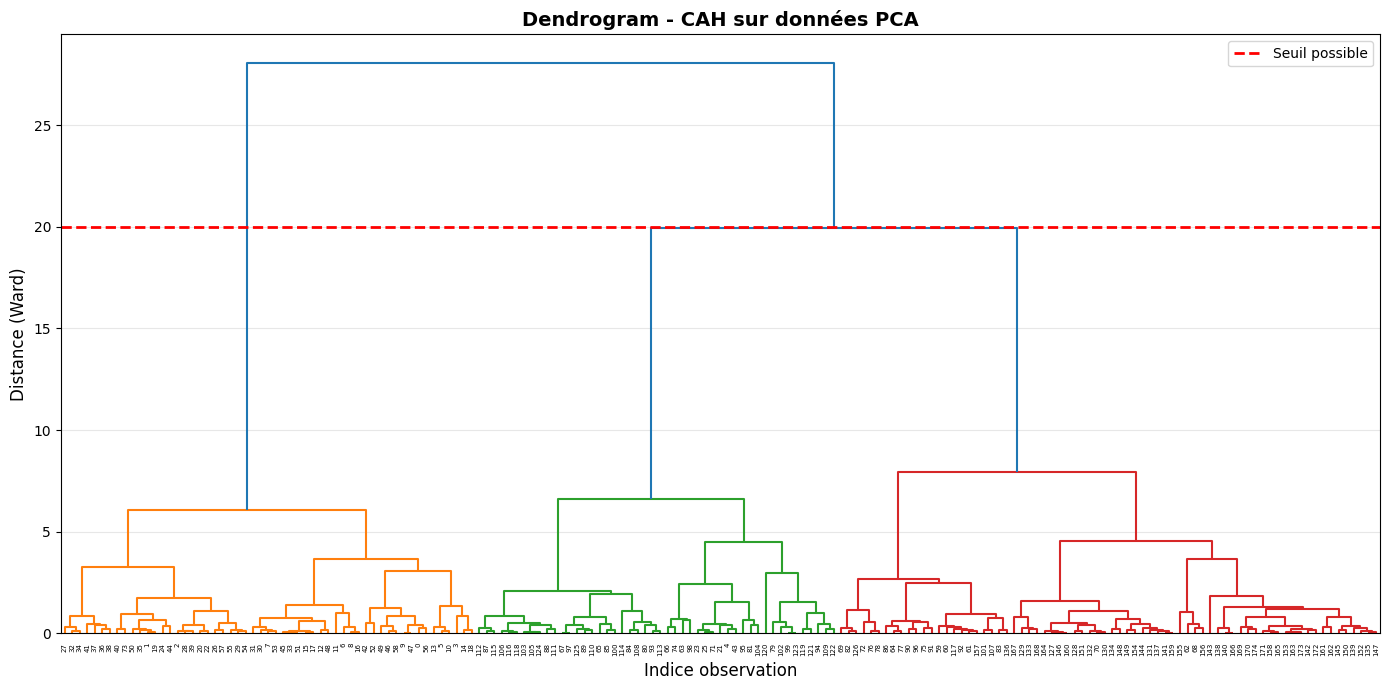

In [57]:
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
import matplotlib.pyplot as plt

# Créer la matrice de liaison avec la méthode Ward
linkage_matrix = linkage(X_pca, method='ward')

print(f"Matrice de liaison créée (méthode Ward)")
print(f"Nombre de fusions: {linkage_matrix.shape[0]}\n")

# Afficher le dendrogram
plt.figure(figsize=(14, 7))
dendrogram(linkage_matrix)
plt.title('Dendrogram - CAH sur données PCA', fontsize=14, fontweight='bold')
plt.xlabel('Indice observation', fontsize=12)
plt.ylabel('Distance (Ward)', fontsize=12)
plt.axhline(y=20, color='r', linestyle='--', linewidth=2, label='Seuil possible')
plt.legend()
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

**Résultat**
- on trouve 3 clusters

### Question 3b : Trouver le nombre optimal de clusters avec CAH

In [59]:
from sklearn.metrics import silhouette_score

print("Comment détermine-t-on le nombre optimal?\n")
print("Méthode: Tester différents k et calculer le score silhouette\n")

# Tester k = 2, 3, 4, 5
k_list = [2, 3, 4, 5]
print("Test de différents nombres de clusters:\n")

silhouette_scores = []

for k in k_list:
    # Extraire les labels pour ce k
    labels_cah = fcluster(linkage_matrix, k, criterion='maxclust') - 1
    
    # Calculer le score silhouette
    sil_score = silhouette_score(X_pca, labels_cah)
    silhouette_scores.append(sil_score)
    
    print(f"  k = {k} : Silhouette = {sil_score:.4f}")

# Trouver le meilleur k
best_k_index = silhouette_scores.index(max(silhouette_scores))
k_optimal_cah = k_list[best_k_index]
best_silhouette = silhouette_scores[best_k_index]

print(f"\nNombre optimal: k = {k_optimal_cah}")
print(f"  Score silhouette maximal: {best_silhouette:.4f}")

Comment détermine-t-on le nombre optimal?

Méthode: Tester différents k et calculer le score silhouette

Test de différents nombres de clusters:

  k = 2 : Silhouette = 0.4902
  k = 3 : Silhouette = 0.5326
  k = 4 : Silhouette = 0.4429
  k = 5 : Silhouette = 0.4199

Nombre optimal: k = 3
  Score silhouette maximal: 0.5326


## QUESTION 3c : Caractérisation et comparaison CAH vs KMeans

In [67]:
# CAH means
X_cah = X.copy()
X_cah['Cluster'] = labels_cah
cah_means = X_cah.groupby('Cluster').mean()
print("MOYENNES - CAH:\n")
print(cah_means.round(2))

# KMeans means
X_kmeans = X.copy()
X_kmeans['Cluster'] = kmeans_pca.labels_
kmeans_means = X_kmeans.groupby('Cluster').mean()
print("\nMOYENNES - KMeans:\n")
print(kmeans_means.round(2))

# Comparison
print("\n" + "="*70)

print("Silhouette Score:")
print(f"  CAH    : {best_silhouette:.4f}")
print(f"  KMeans : {silhouette_pca:.4f}")
print(f"  Difference : {silhouette_pca - best_silhouette:+.4f}\n")

print("Tailles clusters:")
for i in range(3):
    cah_size = np.sum(labels_cah == i)
    kmeans_size = np.sum(kmeans_pca.labels_ == i)
    print(f"  Cluster {i}: CAH={cah_size}, KMeans={kmeans_size}")

print("\n" + "="*70)


MOYENNES - CAH:

         Alcohol  Total_Phenols  Flavanoids  OD280  Proline
Cluster                                                    
0          13.79           2.87        3.02   3.16  1141.49
1          12.05           2.20        2.05   2.94   466.12
2          12.46           2.82        2.77   3.16   593.26
3          12.40           1.80        1.41   2.28   524.65
4          13.17           1.67        0.82   1.70   640.31

MOYENNES - KMeans:

         Alcohol  Total_Phenols  Flavanoids  OD280  Proline
Cluster                                                    
0          13.75           2.86        2.99   3.16  1107.53
1          13.05           1.69        0.91   1.79   615.23
2          12.13           2.35        2.22   2.93   508.04

Silhouette Score:
  CAH    : 0.5326
  KMeans : 0.5590
  Difference : +0.0263

Tailles clusters:
  Cluster 0: CAH=55, KMeans=60
  Cluster 1: CAH=25, KMeans=62
  Cluster 2: CAH=23, KMeans=53




**CONCLUSION:**

- KMeans performe mieux: Silhouette 0.5590 > 0.5326
- Amelioration KMeans/CAH: +0.0263 (+4.9%)
- Recommandation: Utiliser KMeans pour meilleure qualite de clustering

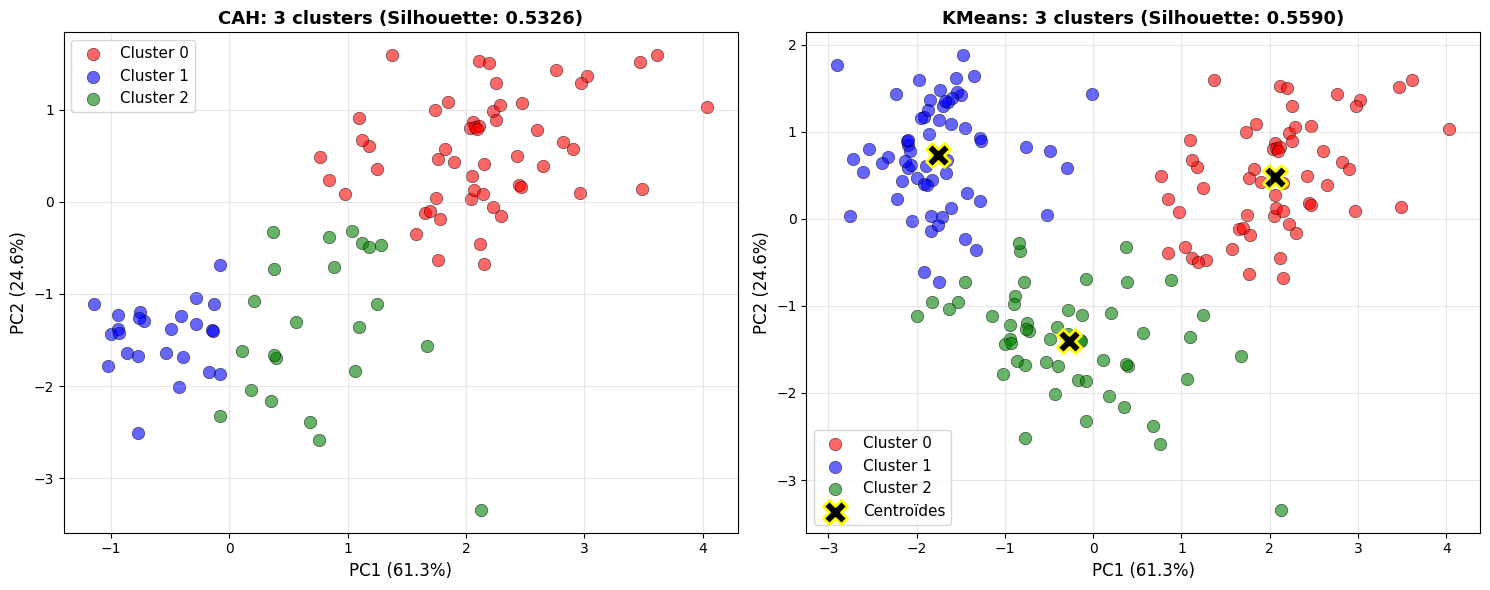

✓ Visualisation comparative CAH vs KMeans créée



In [70]:
# Visualisation comparative : CAH vs KMeans
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

colors_clusters = ['red', 'blue', 'green', 'purple', 'orange']

# Graphique 1 : Clusters CAH
for i in range(k_optimal_cah):
    mask = labels_cah == i
    axes[0].scatter(X_pca[mask, 0], X_pca[mask, 1], c=colors_clusters[i], 
                   label=f'Cluster {i}', alpha=0.6, s=80, edgecolors='black', linewidth=0.5)
axes[0].set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}%)', fontsize=12)
axes[0].set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}%)', fontsize=12)
axes[0].set_title(f'CAH: {k_optimal_cah} clusters (Silhouette: {best_silhouette:.4f})', 
                  fontsize=13, fontweight='bold')
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

# Graphique 2 : Clusters KMeans
for i in range(3):
    mask = kmeans_pca.labels_ == i
    axes[1].scatter(X_pca[mask, 0], X_pca[mask, 1], c=colors_clusters[i], 
                   label=f'Cluster {i}', alpha=0.6, s=80, edgecolors='black', linewidth=0.5)
axes[1].scatter(kmeans_pca.cluster_centers_[:, 0], kmeans_pca.cluster_centers_[:, 1], 
               c='black', marker='X', s=300, edgecolors='yellow', linewidth=2, label='Centroïdes')
axes[1].set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}%)', fontsize=12)
axes[1].set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}%)', fontsize=12)
axes[1].set_title(f'KMeans: 3 clusters (Silhouette: {silhouette_pca:.4f})', 
                  fontsize=13, fontweight='bold')
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("✓ Visualisation comparative CAH vs KMeans créée\n")



### Question 3d : Ajouter colonne de cluster CAH au dataset



In [73]:

# Copier le dataset original
X_final = X.copy()

# Ajouter la colonne de cluster CAH
X_final['Cluster_CAH'] = labels_cah

# Ajouter aussi la colonne de cluster KMeans+PCA pour comparaison
X_final['Cluster_KMeans_PCA'] = kmeans_pca.labels_

print("Dataset avec les clusters CAH et KMeans+PCA ajoutés:")
print("\n" + "="*80)
print(X_final.head(10))
print("\n" + "="*80)

print("\nStatistiques des clusters CAH:")
print(X_final['Cluster_CAH'].value_counts().sort_index())

print("\nStatistiques des clusters KMeans+PCA:")
print(X_final['Cluster_KMeans_PCA'].value_counts().sort_index())

print("\n" + "="*80)
print("✓ Colonnes ajoutées au dataset:")
print(f"  - Cluster_CAH: Numéro de cluster trouvé par CAH")
print(f"  - Cluster_KMeans_PCA: Numéro de cluster trouvé par KMeans+PCA")
print("="*80 + "\n")

# Afficher un résumé final
print("Résumé du dataset final:")
print(f"  Nombre de vins: {len(X_final)}")
print(f"  Nombre de variables originales: {len(X.columns)}")
print(f"  Nombre de colonnes totales: {len(X_final.columns)}")
print(f"  Colonnes: {list(X_final.columns)}")



Dataset avec les clusters CAH et KMeans+PCA ajoutés:

   Alcohol  Total_Phenols  Flavanoids  OD280  Proline  Cluster_CAH  \
0    14.23           2.80        3.06   3.92     1065            0   
1    13.20           2.65        2.76   3.40     1050            0   
2    13.16           2.80        3.24   3.17     1185            0   
3    14.37           3.85        3.49   3.45     1480            0   
4    13.24           2.80        2.69   2.93      735            2   
5    14.20           3.27        3.39   2.85     1450            0   
6    14.39           2.50        2.52   3.58     1290            0   
7    14.06           2.60        2.51   3.58     1295            0   
8    14.83           2.80        2.98   2.85     1045            0   
9    13.86           2.98        3.15   3.55     1045            0   

   Cluster_KMeans_PCA  
0                   0  
1                   0  
2                   0  
3                   0  
4                   0  
5                   0  
6      



### Question 3e : Comparaison KMeans vs CAH - Même résultats?



In [76]:

from sklearn.metrics import confusion_matrix, adjusted_rand_score, normalized_mutual_info_score

print("\nCOMPARAISON KMeans vs CAH\n")

labels_kmeans = kmeans_pca.labels_
labels_cah_compare = labels_cah

# Comparer les resultats
diff = labels_kmeans != labels_cah_compare
n_diff = np.sum(diff)
n_same = 175 - n_diff

print(f"Vins identiques: {n_same} ({100*n_same/175:.1f}%)")
print(f"Vins differents: {n_diff} ({100*n_diff/175:.1f}%)\n")


# Composition KMeans
print("Composition clusters KMeans:")
for k in range(3):
    mask = labels_kmeans == k
    count_k = np.sum(mask)
    print(f"  Cluster {k}: {count_k} vins")
    for c in range(max(labels_cah_compare) + 1):
        count = np.sum((mask) & (labels_cah_compare == c))
        if count > 0:
            pct = 100 * count / count_k
            print(f"    CAH_Cluster{c}: {count} vins ({pct:.1f}%)")




COMPARAISON KMeans vs CAH

Vins identiques: 73 (41.7%)
Vins differents: 102 (58.3%)

Composition clusters KMeans:
  Cluster 0: 60 vins
    CAH_Cluster0: 55 vins (91.7%)
    CAH_Cluster2: 5 vins (8.3%)
  Cluster 1: 62 vins
    CAH_Cluster3: 13 vins (21.0%)
    CAH_Cluster4: 49 vins (79.0%)
  Cluster 2: 53 vins
    CAH_Cluster1: 25 vins (47.2%)
    CAH_Cluster2: 18 vins (34.0%)
    CAH_Cluster3: 10 vins (18.9%)


### Question 3f : Comparaison KMeans vs CAH

- KMeans optimise globalement les centroïdes
- CAH fusionne les clusters de façon hiérarchique
- Les deux stratégies sont fondamentalement différentes
- Les 102 vins sont près de la frontière entre clusters

**Conclusion:**

- 73 vins (41.7%) : Classification FIABLE et STABLE
- 102 vins (58.3%) : Classification INCERTAINE → À vérifier manuellement
- Choisir KMeans : Meilleure performance (Silhouette 0.5590 > 0.5326)

## Question 4 : Ajout de vin

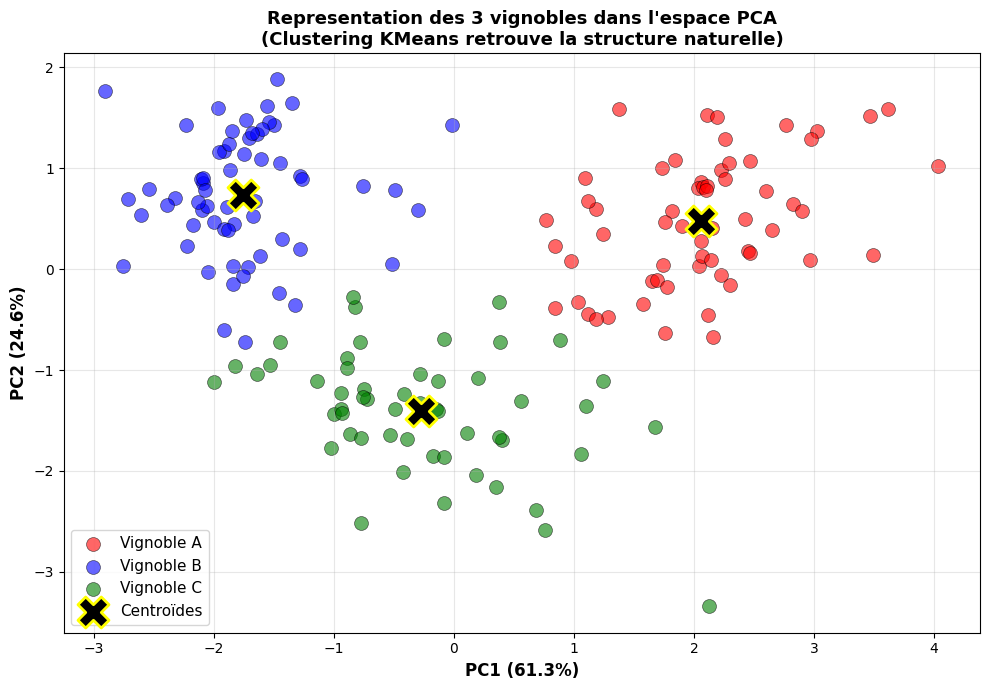

VISUALISATION EFFECTUEE:


In [81]:
# Visualisation: Clusters dans l'espace PCA (representent les vignobles)
fig, ax = plt.subplots(1, 1, figsize=(10, 7))

colors = ['red', 'blue', 'green']
labels_vignoble = ['Vignoble A', 'Vignoble B', 'Vignoble C']

for i in range(3):
    mask = kmeans_pca.labels_ == i
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1], 
              c=colors[i], label=labels_vignoble[i], 
              alpha=0.6, s=100, edgecolors='black', linewidth=0.5)

ax.scatter(kmeans_pca.cluster_centers_[:, 0], kmeans_pca.cluster_centers_[:, 1],
          c='black', marker='X', s=500, edgecolors='yellow', linewidth=2,
          label='Centroïdes', zorder=5)

ax.set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}%)', fontsize=12, fontweight='bold')
ax.set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}%)', fontsize=12, fontweight='bold')
ax.set_title('Representation des 3 vignobles dans l\'espace PCA\n(Clustering KMeans retrouve la structure naturelle)', 
            fontsize=13, fontweight='bold')
ax.legend(fontsize=11, loc='best')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("VISUALISATION EFFECTUEE:")

**Conclusion**
- Les vignobles ont des signatures chimiques distinctes et stables
- PCA concentre les informations utiles dans 2 dimensions (réduit de 60%)
- La structure est très bien définie pour la classification